# 03 — Step Detection and Motion Model

**Milestone M3.** From the cleaned IMU streams we build the *motion model* the
particle filter uses: where each step happens, how far it moves, and in which
direction. Logic lives in `src/imu.py`; plotting in `src/visualization.py`.

Steps here: detect steps from acceleration → estimate heading from the gyroscope
→ assemble the per-step **motion table** → sanity-check it with a **dead-reckoning**
trajectory. We finish with the two calibrations we had to make (step length and
initial heading).

In [1]:
import sys
sys.path.append("../src")
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

import preprocessing
import imu
import visualization as viz

RAW = "../data/raw"

# Load Run 1 and use its known start conditions (start position + initial heading).
run = preprocessing.load_run(1, raw_dir=RAW)
cfg = preprocessing.RUN_START[1]

## Step detection

A step makes the phone shake, so the acceleration *magnitude* (orientation-free)
briefly spikes. We detect steps as peaks in that magnitude, with an adaptive
height threshold (mean + one standard deviation) and a minimum spacing so one step
is not counted twice.

detected steps : 277
cadence        : 1.40 steps/s


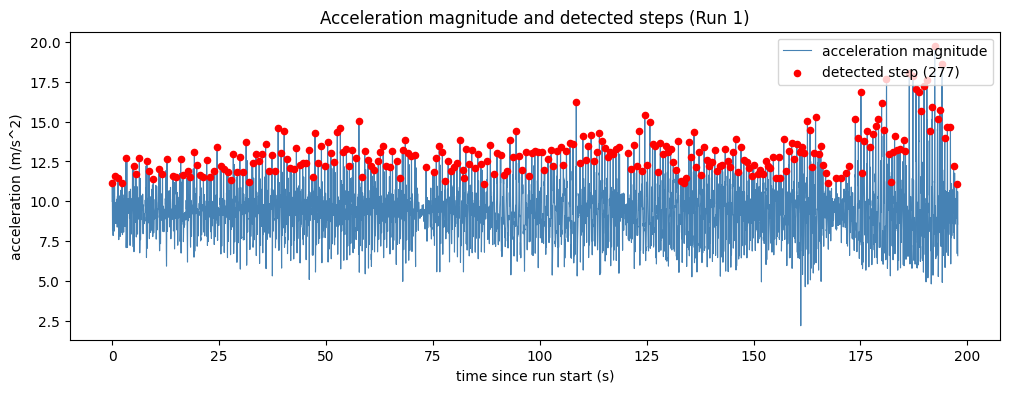

In [2]:
steps = imu.detect_steps(run.accel)
print("detected steps :", len(steps))
print("cadence        : %.2f steps/s" % (len(steps) / run.duration_s))

viz.plot_acceleration_with_steps(run.accel, steps, run_id=1)
plt.show()

## Heading from the gyroscope

The person turns about the vertical axis. We estimate the vertical direction from
gravity (the mean accelerometer vector) and project the gyroscope onto it to get
the yaw rate, then integrate it into a heading. A constant gyro bias is removed
(the median yaw rate), and the heading is anchored to the run's known start
direction (`initial_heading`).

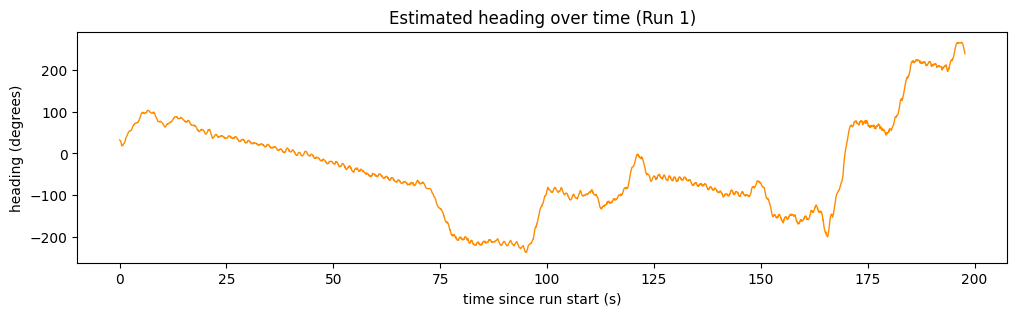

In [3]:
gravity = imu.estimate_gravity_direction(run.accel)
heading = imu.heading_from_gyro(run.gyro, gravity,
                                initial_heading=cfg["initial_heading"])

viz.plot_heading(heading, run_id=1)
plt.show()

## The per-step motion table

For each step we record its time, an assumed step length, the heading at that
time, and an angular uncertainty (`heading_sigma`). This is the "error-prone
motion sector" the assignment asks for and the motion input to the filter.

In [4]:
motion = imu.build_motion_table(run, initial_heading=cfg["initial_heading"])
motion.head()

,t_rel,step_length,heading,heading_sigma
0,0.002,0.5,0.560300,0.261799
1,0.523,0.5,0.323713,0.261799
2,1.333,0.5,0.529523,0.261799
3,2.320,0.5,0.928129,0.261799
4,3.170,0.5,1.139286,0.261799


## Dead-reckoning sanity check

Walking step-by-step along the headings, with no map or BLE, gives a
dead-reckoning path. It drifts over a few minutes (residual heading error) — which
is exactly why the particle filter adds the map and BLE — but its overall shape
should look like corridor walking.

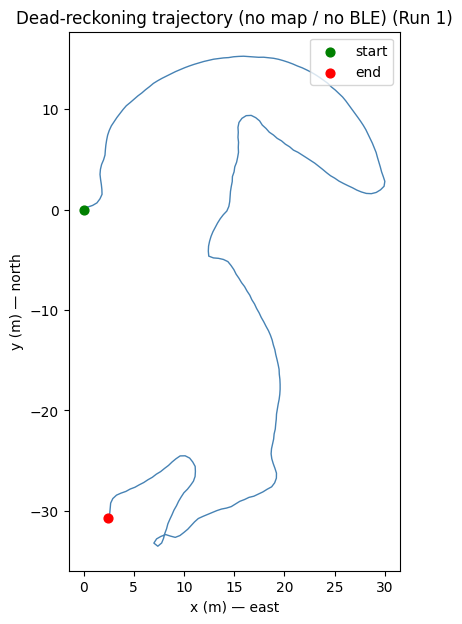

In [5]:
dead_reckoning = imu.dead_reckoning(motion, start=cfg["start"])
viz.plot_dead_reckoning(dead_reckoning, run_id=1)
plt.show()

## Calibration 1 — step length (decision D10)

The step length started as a guess (0.70 m) but made the estimated path far too
long. Measuring a clean, straight, single-floor corridor leg against the door
references gives the real step length: `distance / number_of_steps`.

In [6]:
import building
import evaluation

# The reference workbook lives under ../assignment when running from notebooks/.
reference = evaluation.load_reference(1, reference_file="../assignment/Paths_references.xlsx")
doors = building.door_positions()

# Run 1's first floor-0 leg runs from door 024 to door 018.
t_start = reference[(reference["floor"] == 0) & (reference["room"] == "24")].iloc[0]["t_rel"]
t_end = reference[(reference["floor"] == 0) & (reference["room"] == "18")].iloc[0]["t_rel"]
distance = abs(doors[(0, "18")][0] - doors[(0, "24")][0])
leg_steps = steps[(steps["t_rel"] >= t_start) & (steps["t_rel"] <= t_end)]

print("corridor distance   : %.1f m" % distance)
print("steps during the leg : %d" % len(leg_steps))
print("implied step length  : %.2f m" % (distance / len(leg_steps)))

corridor distance   : 27.0 m
steps during the leg : 67
implied step length  : 0.40 m


Doing this for every run gives implied step lengths of about **0.40–0.53 m** on
Runs 1, 3, 4 (Run 2's short leg under-counts and is an outlier). We adopt a single
calibrated constant of **0.50 m**, which roughly halved the door-checkpoint error
on every run. See decision D10.

## Calibration 2 — per-run initial heading (decision D11)

The gyro gives only *relative* heading; its absolute anchor depends on how the
phone sat in the pocket (an unknown per-run yaw offset). Leaving it at 0 (east) for
every run launched non-eastward runs the wrong way. We calibrate the initial
heading by aligning each run's first straight corridor leg to the known corridor
axis, and store the result in `preprocessing.RUN_START`.

In [7]:
import numpy as np
start_conditions = pd.DataFrame([
    {"run": run_id,
     "start_x": cfg_i["start"][0], "start_y": cfg_i["start"][1],
     "floor": cfg_i["floor"],
     "initial_heading_deg": round(np.degrees(cfg_i["initial_heading"]), 1)}
    for run_id, cfg_i in preprocessing.RUN_START.items()
])
start_conditions

,run,start_x,start_y,floor,initial_heading_deg
0,1,0.0,0.0,0,32.1
1,2,17.5,0.0,0,10.4
2,3,33.0,0.0,0,-132.3
3,4,2.0,0.0,0,147.4


Runs 1 and 3 improve markedly with the calibrated heading; Runs 2 and 4 have weak
anchors (short/under-counted leg, and floor-0 walking only at the run's end) — an
honest limitation documented in D11.

Next: **04 — Building model, BLE observation model, and the particle filter.**